In [15]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [16]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from src.data.analysis import Circle
from src.data.detector import DetectorData

## Configuration

In [17]:
# Data path - single large foil from 2025-11-25
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25")
INPUT_FILE = DATA_PATH / 'mbo_aic144_single_foil_processed.pkl'

# Visualization parameters
PIXEL_SIZE_MM = 0.042         # Pixel size in mm
LOW_THRESHOLD_VALUE = 50      # Pixel value below which pixels are white

## Load Processed Data

In [18]:
# Load processed foil data (includes refined circle)
with open(INPUT_FILE, 'rb') as f:
    foil_data: DetectorData = pickle.load(f)

print(f"Loaded data from: {INPUT_FILE}")
print(f"  Image shape: {foil_data.raw.image.shape}")
print(f"  Image size: {foil_data.raw.image.shape[0] * PIXEL_SIZE_MM:.1f} x {foil_data.raw.image.shape[1] * PIXEL_SIZE_MM:.1f} mm")
print(f"  Refined circle: center=({foil_data.circle.x:.1f}, {foil_data.circle.y:.1f}) px")
print(f"                  center=({foil_data.circle.x * PIXEL_SIZE_MM:.2f}, {foil_data.circle.y * PIXEL_SIZE_MM:.2f}) mm")
print(f"                  radius={foil_data.circle.r:.1f} px = {foil_data.circle.r * PIXEL_SIZE_MM:.2f} mm")

Loaded data from: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25\mbo_aic144_single_foil_processed.pkl
  Image shape: (1024, 1024)
  Image size: 43.0 x 43.0 mm
  Refined circle: center=(532.5, 500.7) px
                  center=(22.36, 21.03) mm
                  radius=241.3 px = 10.14 mm


## Rotate Image 180 Degrees

In [19]:
# Rotate image 180 degrees (equivalent to np.rot90 twice)
image_original = foil_data.raw.image
image_rotated = np.rot90(image_original, k=2)  # k=2 means 180 degree rotation

# Update circle center after 180 degree rotation
# (x, y) -> (width - x, height - y)
h, w = image_original.shape
circle_original = foil_data.circle
circle_rotated = Circle(
    x=w - circle_original.x,
    y=h - circle_original.y,
    r=circle_original.r
)

print(f"Original image shape: {image_original.shape}")
print(f"Rotated image shape: {image_rotated.shape}")
print(f"\nOriginal circle center: ({circle_original.x:.1f}, {circle_original.y:.1f}) px")
print(f"Rotated circle center:  ({circle_rotated.x:.1f}, {circle_rotated.y:.1f}) px")

Original image shape: (1024, 1024)
Rotated image shape: (1024, 1024)

Original circle center: (532.5, 500.7) px
Rotated circle center:  (491.5, 523.3) px


## Visualization Functions

In [20]:
def create_white_green_red_cmap():
    """Colormap: white→green→red. Set values below threshold to NaN for white."""
    cmap = LinearSegmentedColormap.from_list('wgr', ['white', 'green', 'red'])
    cmap.set_bad('white')
    return cmap


def plot_foil_with_profiles(image, circle, px_mm, threshold, title="", margin_mm=4.0):
    """Plot foil cropped to circle with margin, colormap and profiles."""
    h, w = image.shape
    cx, cy = int(circle.x), int(circle.y)
    r_mm = circle.r * px_mm
    
    # Crop region: circle ± (radius + margin)
    margin_px = int(margin_mm / px_mm)
    r_px = int(circle.r)
    x0 = max(0, cx - r_px - margin_px)
    x1 = min(w, cx + r_px + margin_px)
    y0 = max(0, cy - r_px - margin_px)
    y1 = min(h, cy + r_px + margin_px)
    
    # Crop image and adjust coordinates
    img_crop = image[y0:y1, x0:x1].astype(np.float32).copy()
    cx_crop, cy_crop = cx - x0, cy - y0
    hc, wc = img_crop.shape
    
    # Extent in mm (relative to crop origin)
    extent = [0, wc * px_mm, hc * px_mm, 0]
    cx_mm, cy_mm = cx_crop * px_mm, cy_crop * px_mm
    
    vmax = np.nanmax(img_crop)
    img_crop[img_crop < threshold] = np.nan
    
    # Extract profiles from cropped image
    pw = 5
    h_profile = image[y0:y1, x0:x1][max(0,cy_crop-pw):min(hc,cy_crop+pw), :].mean(axis=0)
    v_profile = image[y0:y1, x0:x1][:, max(0,cx_crop-pw):min(wc,cx_crop+pw)].mean(axis=1)
    x_mm, y_mm = np.arange(wc) * px_mm, np.arange(hc) * px_mm
    
    # Create figure
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_axes([0.1, 0.35, 0.6, 0.55])
    ax_h = fig.add_axes([0.1, 0.08, 0.6, 0.22])
    ax_v = fig.add_axes([0.73, 0.35, 0.12, 0.55])
    ax_cb = fig.add_axes([0.73, 0.08, 0.02, 0.22])
    
    # Main image
    im = ax.imshow(img_crop, cmap=create_white_green_red_cmap(), vmin=0, vmax=vmax, extent=extent, aspect='equal')
    ax.axhline(cy_mm, c='k', lw=1.5, alpha=0.8)
    ax.axvline(cx_mm, c='k', lw=1.5, alpha=0.8)
    if circle.r > 0:
        ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=2))
        ax.scatter(cx_mm, cy_mm, c='blue', s=50, marker='+', lw=2)
    
    # 1mm grid
    ax.set_xticks(np.arange(0, extent[1], 1))
    ax.set_yticks(np.arange(0, extent[2], 1))
    ax.grid(True, lw=0.5, c='k', alpha=0.3)
    ax.set(xlabel='x [mm]', ylabel='y [mm]', title=title)
    
    # Horizontal profile
    ax_h.plot(x_mm, h_profile, 'b-', lw=1)
    ax_h.axvline(cx_mm, c='r', ls='--', alpha=0.7)
    if circle.r > 0:
        ax_h.axvline(cx_mm - r_mm, c='g', ls=':', alpha=0.7)
        ax_h.axvline(cx_mm + r_mm, c='g', ls=':', alpha=0.7)
    ax_h.set(xlabel='x [mm]', ylabel='Value', xlim=(0, extent[1]))
    ax_h.grid(True, lw=0.5, c='k', alpha=0.3)
    
    # Vertical profile
    ax_v.plot(v_profile, y_mm, 'b-', lw=1)
    ax_v.axhline(cy_mm, c='r', ls='--', alpha=0.7)
    if circle.r > 0:
        ax_v.axhline(cy_mm - r_mm, c='g', ls=':', alpha=0.7)
        ax_v.axhline(cy_mm + r_mm, c='g', ls=':', alpha=0.7)
    ax_v.set(xlabel='Value', ylabel='y [mm]', ylim=(extent[2], 0))
    ax_v.grid(True, lw=0.5, c='k', alpha=0.3)
    
    plt.colorbar(im, cax=ax_cb, label='Value')
    plt.show()

## Rotated Image Visualization

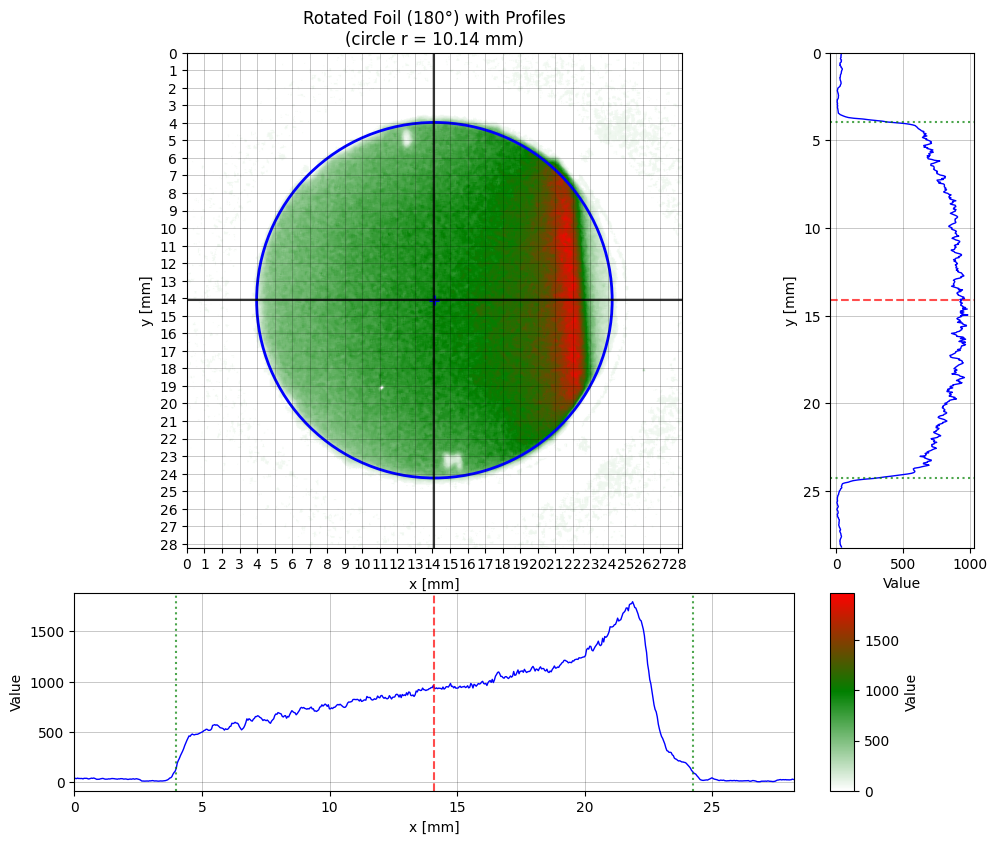

In [21]:
# Plot rotated image with profiles through refined circle center
plot_foil_with_profiles(
    image_rotated, 
    circle_rotated, 
    PIXEL_SIZE_MM,
    LOW_THRESHOLD_VALUE,
    title=f'Rotated Foil (180°) with Profiles\n(circle r = {circle_rotated.r * PIXEL_SIZE_MM:.2f} mm)'
)